In [112]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path().resolve().parent))

from src.data import get_data
from src.features import generate_features
from src.backtest import backtest, results_table, optimize, window_table
from src.strategy import momentum_trend_strategy, momentum_volatility_strategy, momentum_voluratio_strategy
from src.visualization import plot_performance, plot_features

In [113]:
base_df = get_data('AAPL', '2021-01-01', '2026-01-01')
base_df = generate_features(base_df)

[*********************100%***********************]  1 of 1 completed


# Features 

/Users/noel/Desktop/quant-research-system/src/visualization.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


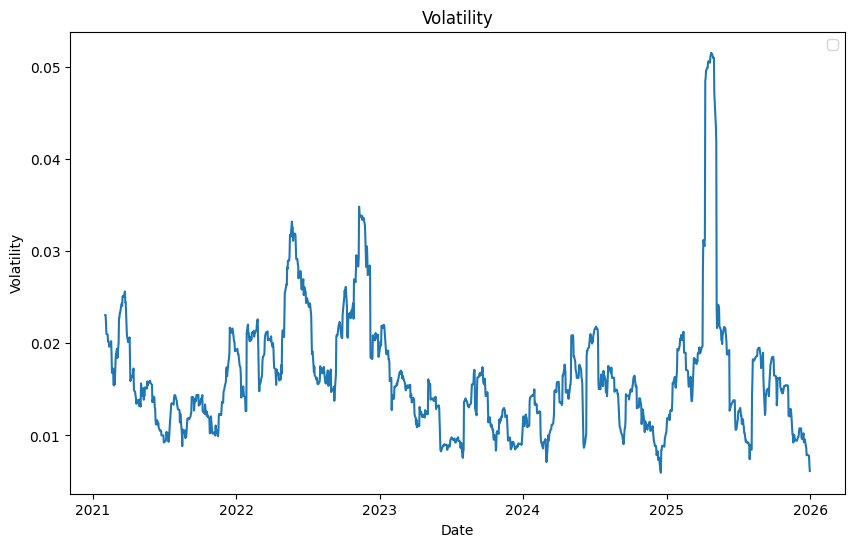

/Users/noel/Desktop/quant-research-system/src/visualization.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


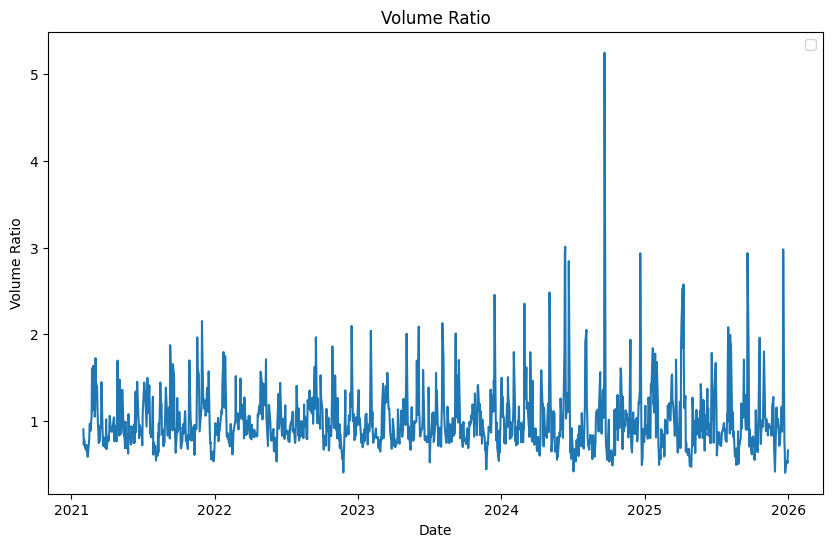

/Users/noel/Desktop/quant-research-system/src/visualization.py:50: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


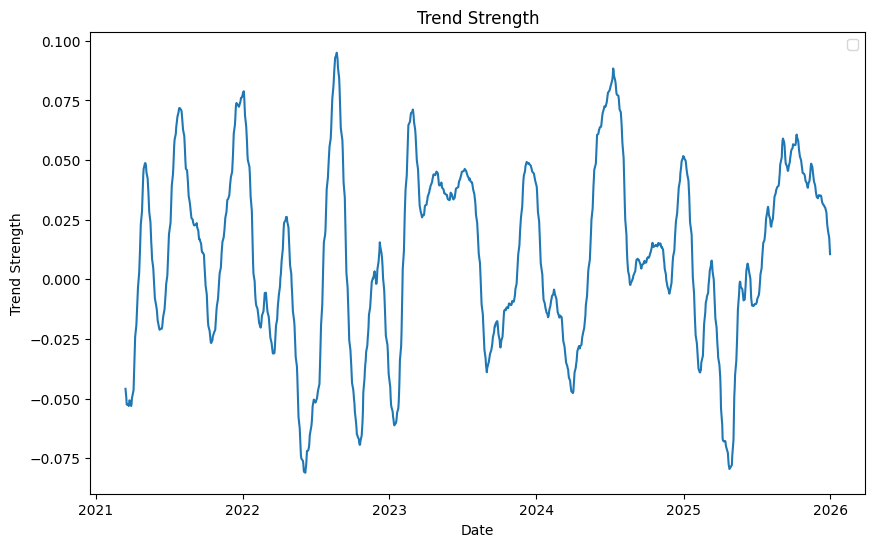

In [114]:
plot_features(base_df)

# Filtered Strategies

## Momentum + Trend Strategy

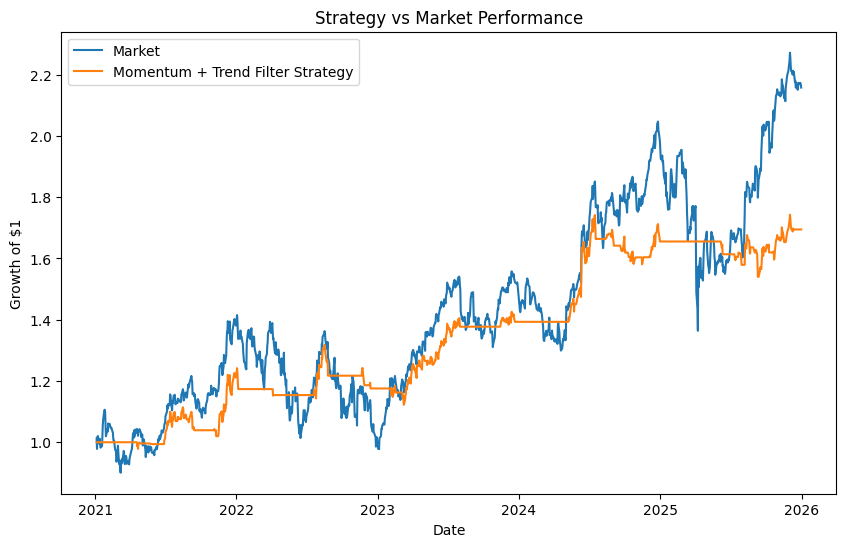

In [115]:
df = base_df.copy()
df = momentum_trend_strategy(df)
df = backtest(df)

plot_performance(df)

In [116]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Momentum + Trend Filter,0.921790,0.123169,-0.148498


## Momentum + Low Volatility Strategy

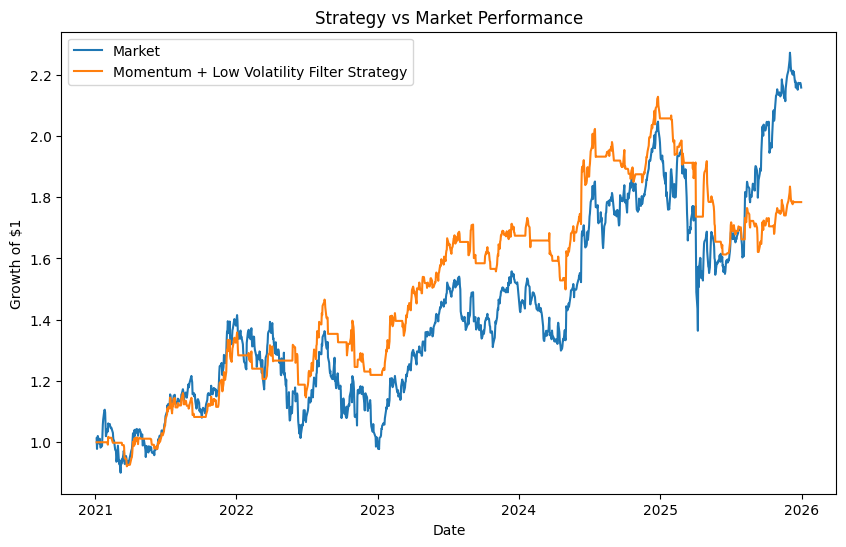

In [117]:
df = base_df.copy()
df = momentum_volatility_strategy(df)
df = backtest(df)

plot_performance(df)

In [118]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Momentum + Low Volatility Filter,0.742794,0.177896,-0.241998


## Momentum + Volume Ratio Strategy

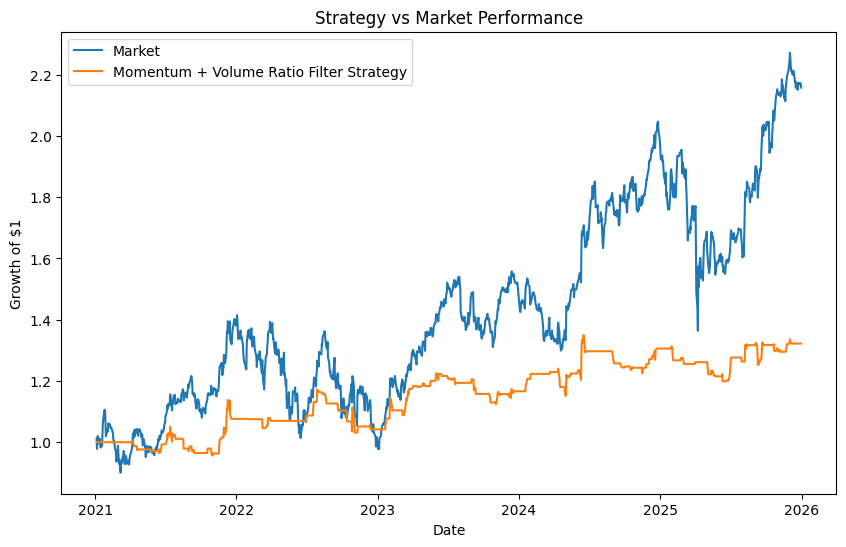

In [119]:
df = base_df.copy()
df = momentum_voluratio_strategy(df)
df = backtest(df)

plot_performance(df)

In [120]:
results_table(df)

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Momentum + Volume Ratio Filter,0.547273,0.114331,-0.120214


# Parameter Testing

In [121]:
windows = range(1, 51)
strategies = [
    ("Momentum + Trend Strength", momentum_trend_strategy, "mo_tr", []),
    ("Momentum + Rolling Volatility", momentum_volatility_strategy, "mo_vo", []),
    ("Momentum + Volume Ratio", momentum_voluratio_strategy, "mo_vr", [])
]

In [124]:
df = base_df.copy()
window_table(df, strategies, [5, 10, 20, 50])

,Strategy,Window,Sharpe,Volatility,Max DD
0,Momentum + Trend Strength,5,0.179021,0.124988,-0.252912
1,Momentum + Trend Strength,10,0.921790,0.123169,-0.148498
2,Momentum + Trend Strength,20,0.704455,0.145119,-0.221308
3,Momentum + Trend Strength,50,0.773479,0.161059,-0.173738
4,Momentum + Rolling Volatility,5,0.593242,0.177728,-0.182804
5,Momentum + Rolling Volatility,10,0.742794,0.177896,-0.241998
6,Momentum + Rolling Volatility,20,0.809953,0.176537,-0.212237
7,Momentum + Rolling Volatility,50,0.676844,0.179370,-0.243726
8,Momentum + Volume Ratio,5,0.588995,0.118050,-0.123592
9,Momentum + Volume Ratio,10,0.547273,0.114331,-0.120214


Momentum + Trend Strength
Market Returns Sharpe Ratio: 0.6934950629830158
Best Momentum + Trend Strength Strategy window: 14
Best Sharpe ratio: 1.0088


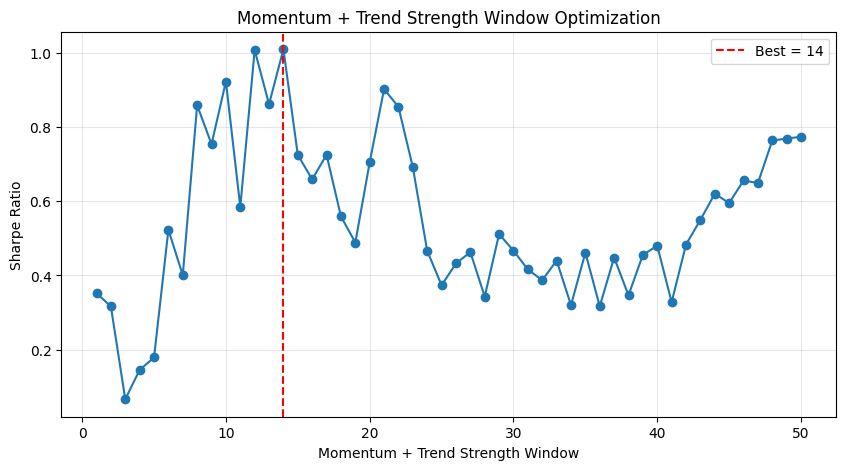

Momentum + Rolling Volatility
Market Returns Sharpe Ratio: 0.6934950629830158
Best Momentum + Rolling Volatility Strategy window: 14
Best Sharpe ratio: 1.0585


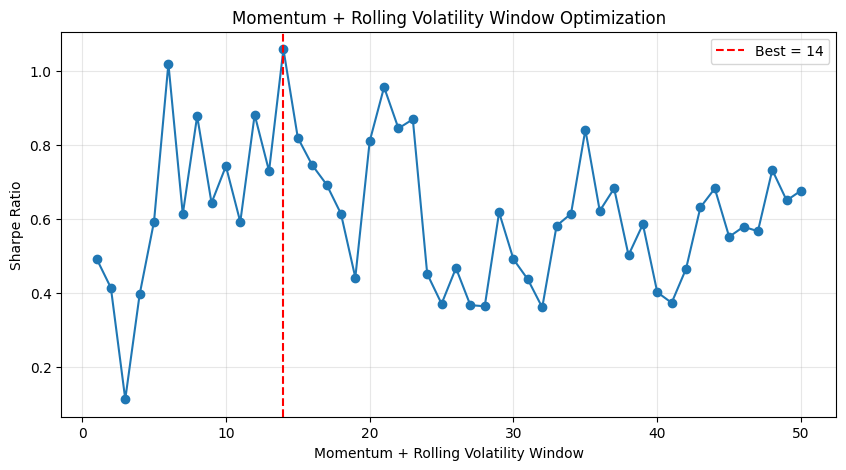

Momentum + Volume Ratio
Market Returns Sharpe Ratio: 0.6934950629830158
Best Momentum + Volume Ratio Strategy window: 21
Best Sharpe ratio: 0.9501


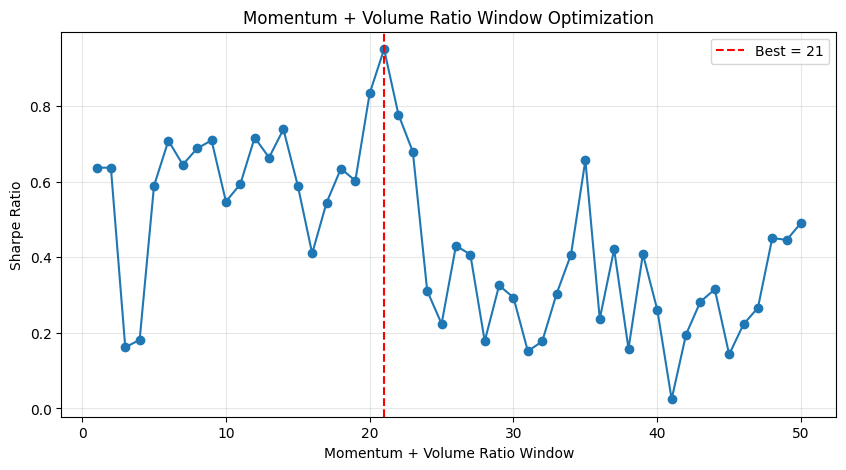

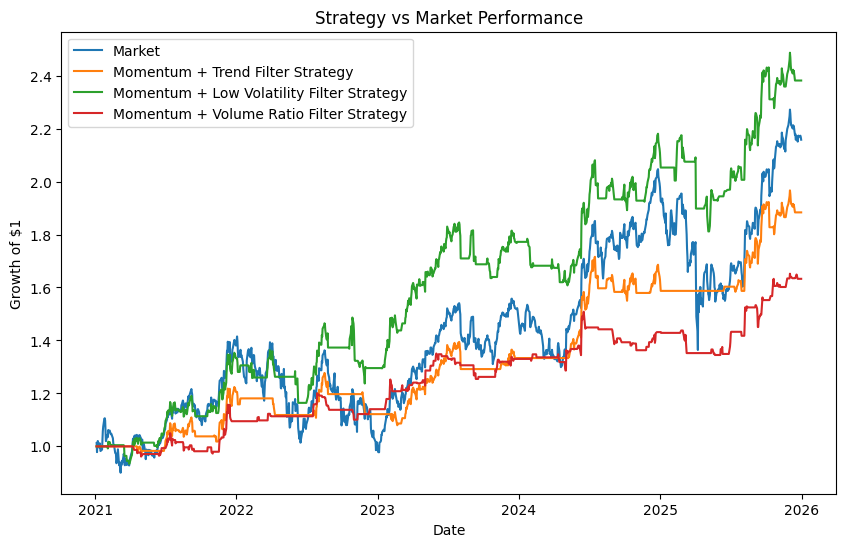

,Strategy,Sharpe,Volatility,Max DD
0,Market,0.693495,0.278515,-0.333605
1,Momentum + Trend Filter,1.008839,0.135120,-0.154756
2,Momentum + Low Volatility Filter,1.058521,0.180032,-0.169209
3,Momentum + Volume Ratio Filter,0.950102,0.109975,-0.108300


In [123]:
df = base_df.copy()

optimize(df, strategies, windows)